# Урок 3. Деревья, бустинг и SHAP

🎯 **Цели урока**

- увидеть, как решающее дерево делит данные и как оно переобучается;
- сравнить случайный лес, HistGradientBoosting и CatBoost с логистической регрессией из урока 1;
- настроить бустинг с ранней остановкой;
- объяснить модель через SHAP: глобально и для одного человека.

📖 **Теория:** раздел «Деревья и ансамбли».

In [1]:
import time
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from mlcourse import fetch

warnings.filterwarnings("ignore", message="IProgress not found")  # shap импортирует tqdm для Jupyter
import shap  # noqa: E402

## 1. Данные

Тот же Adult и то же разбиение, что в уроке 1: результаты можно сравнивать напрямую.

In [2]:
COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status", "occupation",
    "relationship", "race", "sex", "capital_gain", "capital_loss", "hours_per_week", "native_country", "income",
]
with zipfile.ZipFile(fetch("adult") / "adult.zip") as z:
    df = pd.concat([pd.read_csv(z.open(name), names=COLUMNS, skipinitialspace=True, na_values="?", skiprows=skip)
                    for name, skip in [("adult.data", 0), ("adult.test", 1)]], ignore_index=True)
y = (df["income"].str.rstrip(".") == ">50K").astype(int)
X = df.drop(columns=["income", "fnlwgt"])
numeric = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
categorical = [c for c in X.columns if c not in numeric]
X[categorical] = X[categorical].fillna("unknown")  # пропуск — тоже информация: отдельная категория

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
results = {}


def evaluate(name, proba, seconds):
    results[name] = {"ROC-AUC": roc_auc_score(y_test, proba), "PR-AUC": average_precision_score(y_test, proba),
                     "обучение, с": seconds}
    print(f"{name:28} ROC-AUC {results[name]['ROC-AUC']:.4f}   PR-AUC {results[name]['PR-AUC']:.4f}   {seconds:.1f} с")


start = time.perf_counter()
logreg = make_pipeline(
    ColumnTransformer([("num", StandardScaler(), numeric),
                       ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), categorical)]),
    LogisticRegression(max_iter=2000),
).fit(X_train, y_train)
evaluate("логистическая регрессия", logreg.predict_proba(X_test)[:, 1], time.perf_counter() - start)

логистическая регрессия      ROC-AUC 0.9091   PR-AUC 0.7683   0.3 с


## 2. Решающее дерево

Деревьям не нужны масштабирование и one-hot: достаточно пронумеровать категории.

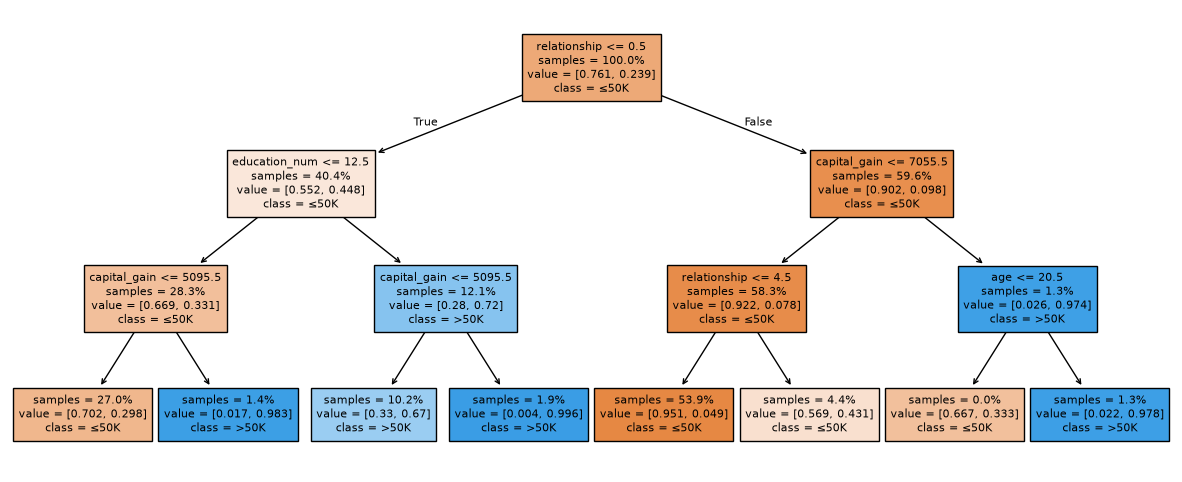

In [3]:
ordinal = ColumnTransformer([("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                              categorical)], remainder="passthrough", verbose_feature_names_out=False)
tree3 = make_pipeline(ordinal, DecisionTreeClassifier(max_depth=3, random_state=0)).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(15, 6))
plot_tree(tree3[-1], feature_names=list(tree3[0].get_feature_names_out()), class_names=["≤50K", ">50K"],
          filled=True, impurity=False, proportion=True, fontsize=8, ax=ax)
plt.show()

Первый вопрос — `relationship <= 0.5`. Категории пронумерованы по алфавиту, код 0 — `Husband`:
дерево сразу отделило женатых мужчин, среди которых высокий доход у 45%, от всех остальных (10%).
Жён (`Wife`, код 5) оно отделяет уровнем ниже, в правой ветке. Дальше в ход идут образование
и прирост капитала. `value` в каждом узле — доли классов среди попавших в него людей.

Как дерево переобучается с ростом глубины:

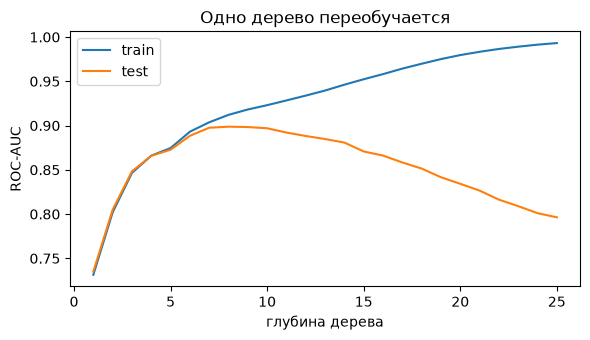

дерево (глубина 8)           ROC-AUC 0.8988   PR-AUC 0.7590   0.1 с


In [4]:
depths = range(1, 26)
scores = []
for d in depths:
    m = make_pipeline(ordinal, DecisionTreeClassifier(max_depth=d, random_state=0)).fit(X_train, y_train)
    scores.append((roc_auc_score(y_train, m.predict_proba(X_train)[:, 1]),
                   roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])))
scores = np.array(scores)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(depths, scores[:, 0], label="train")
ax.plot(depths, scores[:, 1], label="test")
ax.set(xlabel="глубина дерева", ylabel="ROC-AUC", title="Одно дерево переобучается")
ax.legend()
plt.tight_layout()
plt.show()

best_depth = int(depths[np.argmax(scores[:, 1])])
start = time.perf_counter()
tree = make_pipeline(ordinal, DecisionTreeClassifier(max_depth=best_depth, random_state=0)).fit(X_train, y_train)
evaluate(f"дерево (глубина {best_depth})", tree.predict_proba(X_test)[:, 1], time.perf_counter() - start)

Глубину мы здесь подобрали по тесту — ради наглядности графика. В реальной работе так нельзя,
подбирают на валидации (урок 1).

## 3. Случайный лес

Много глубоких деревьев на бутстреп-выборках со случайными подмножествами признаков — и усреднение.

In [5]:
start = time.perf_counter()
forest = make_pipeline(ordinal, RandomForestClassifier(n_estimators=300, min_samples_leaf=5, n_jobs=-1,
                                                       random_state=0)).fit(X_train, y_train)
evaluate("случайный лес", forest.predict_proba(X_test)[:, 1], time.perf_counter() - start)

случайный лес                ROC-AUC 0.9198   PR-AUC 0.8122   1.3 с


## 4. Градиентный бустинг

### HistGradientBoosting из scikit-learn

Признаки группируются в корзины (гистограммы), поэтому обучение очень быстрое. Категориальные
признаки поддерживаются нативно, если у столбца тип `category`.

In [6]:
def as_category(frame, reference=None):
    frame = frame.copy()
    for c in categorical:
        cats = reference[c].cat.categories if reference is not None else None
        frame[c] = pd.Categorical(frame[c], categories=cats)
    return frame


Xh_train = as_category(X_train)
Xh_test = as_category(X_test, reference=Xh_train)

start = time.perf_counter()
hgb = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0).fit(Xh_train, y_train)
evaluate("HistGradientBoosting", hgb.predict_proba(Xh_test)[:, 1], time.perf_counter() - start)
print("деревьев после ранней остановки:", hgb.n_iter_)

HistGradientBoosting         ROC-AUC 0.9308   PR-AUC 0.8351   0.9 с
деревьев после ранней остановки: 87


### CatBoost

Отдельно отложим валидационную выборку для ранней остановки: бустинг добавляет деревья, пока
метрика на валидации растёт, и останавливается через 100 итераций без улучшения.

CatBoost                     ROC-AUC 0.9307   PR-AUC 0.8355   13.0 с
лучшая итерация: 712


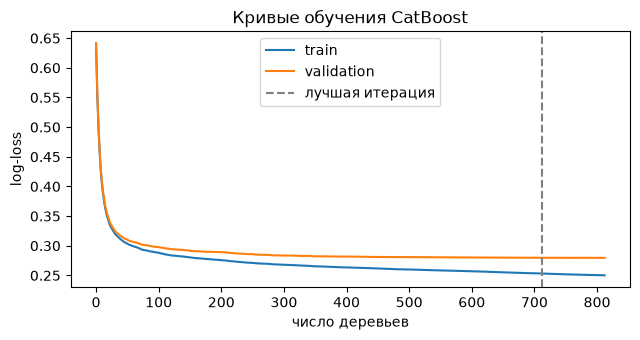

In [7]:
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.15, stratify=y_train, random_state=0)

start = time.perf_counter()
cat_model = CatBoostClassifier(iterations=3000, learning_rate=0.05, depth=6, eval_metric="AUC",
                               early_stopping_rounds=100, random_seed=0, verbose=False,
                               allow_writing_files=False)  # не создавать папку catboost_info
cat_model.fit(X_fit, y_fit, cat_features=categorical, eval_set=(X_val, y_val))
evaluate("CatBoost", cat_model.predict_proba(X_test)[:, 1], time.perf_counter() - start)
print("лучшая итерация:", cat_model.get_best_iteration())

history = cat_model.get_evals_result()
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(history["learn"]["Logloss"], label="train")
ax.plot(history["validation"]["Logloss"], label="validation")
ax.axvline(cat_model.get_best_iteration(), ls="--", color="gray", label="лучшая итерация")
ax.set(xlabel="число деревьев", ylabel="log-loss", title="Кривые обучения CatBoost")
ax.legend()
plt.tight_layout()
plt.show()

Потери на train падают всё время, на валидации выходят на плато. Дальше новые деревья подгоняют
уже шум, и ранняя остановка это отсекает.

## 5. Сравнение

In [8]:
pd.DataFrame(results).T.round(4)

,ROC-AUC,PR-AUC,"обучение, с"
логистическая регрессия,0.9091,0.7683,0.2569
дерево (глубина 8),0.8988,0.7590,0.0862
случайный лес,0.9198,0.8122,1.2691
HistGradientBoosting,0.9308,0.8351,0.9239
CatBoost,0.9307,0.8355,13.0482


Бустинги прибавляют к логистической регрессии две сотых ROC-AUC и почти семь сотых PR-AUC.
На такой изученной задаче это заметный шаг. CatBoost и HistGradientBoosting здесь равны,
но HistGradientBoosting обучился в несколько раз быстрее. Преимущества CatBoost видны на данных,
где много категорий с большим числом значений, и в устойчивости настроек по умолчанию.

## 6. SHAP: почему модель так решила

Встроенная важность признаков CatBoost и средние по модулю SHAP-значения:

In [9]:
explainer = shap.TreeExplainer(cat_model)
sample = X_test.iloc[:2000]
sv = explainer(sample)

importance = pd.DataFrame({
    "CatBoost importance": cat_model.get_feature_importance(),
    "mean |SHAP|": np.abs(sv.values).mean(axis=0),
}, index=X.columns).sort_values("mean |SHAP|", ascending=False)
importance.round(3)

,CatBoost importance,mean |SHAP|
marital_status,19.751,0.817
age,12.723,0.781
relationship,7.657,0.495
capital_gain,22.822,0.459
occupation,6.789,0.412
hours_per_week,7.139,0.385
education_num,5.123,0.380
education,3.622,0.210
capital_loss,8.444,0.135
workclass,2.720,0.121


Рейтинги расходятся: встроенная важность CatBoost ставит на первое место прирост капитала,
SHAP — семейное положение и возраст. Встроенная важность измеряет, насколько признак улучшал
разбиения при обучении. SHAP измеряет средний вклад в предсказания. Для объяснения модели
надёжнее SHAP.

«Пчелиный рой» (beeswarm): каждая точка — человек, по горизонтали — вклад признака в логарифм шансов,
цвет — значение признака. Для категориальных признаков цвет не определён (серый).

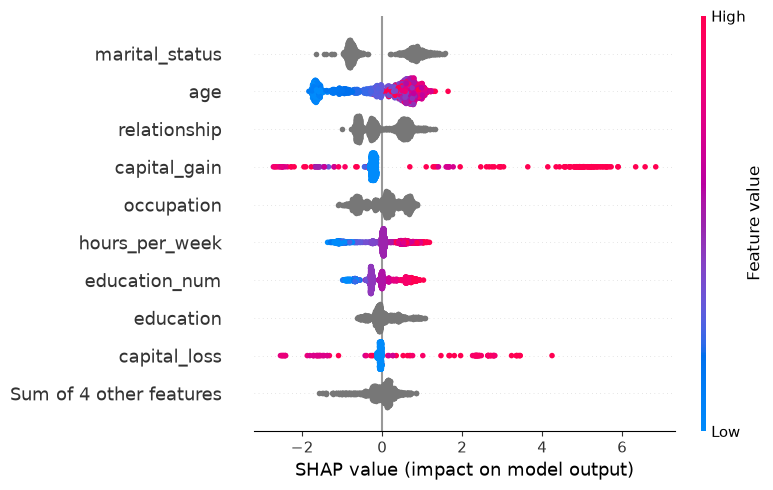

In [10]:
shap.plots.beeswarm(sv, max_display=10, show=False)
plt.gcf().set_size_inches(8, 5)
plt.tight_layout()
plt.show()

Возраст: у молодых (синие точки) вклад отрицательный — шансы на высокий доход ниже. Прирост
капитала: у большинства он нулевой и почти не влияет, а у немногих с большим приростом
обычно резко повышает шансы. Это нелинейность, которую логистическая регрессия на исходных признаках не выразит.

### Объяснение для одного человека

{'age': 64, 'workclass': 'Self-emp-not-inc', 'education': 'Masters', 'education_num': 14, 'marital_status': 'Married-civ-spouse', 'occupation': 'Prof-specialty', 'relationship': 'Husband', 'race': 'White', 'sex': 'Male', 'capital_gain': 0, 'capital_loss': 2415, 'hours_per_week': 50, 'native_country': 'United-States'}


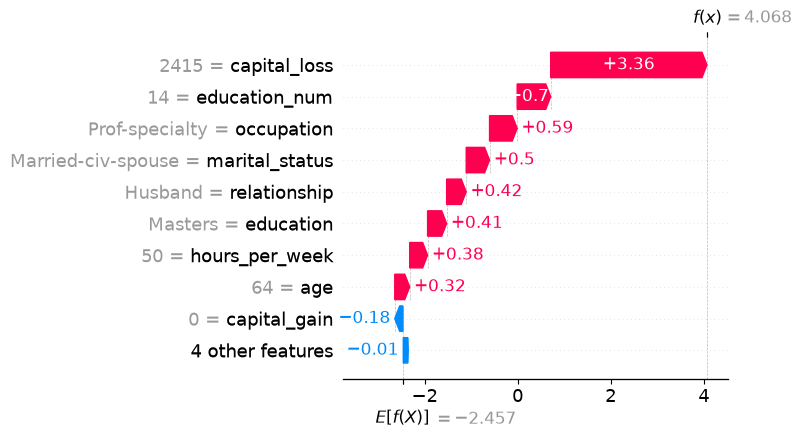

In [11]:
i = int(np.argmax(cat_model.predict_proba(sample)[:, 1] > 0.9))  # первый уверенный «>50K»
print(sample.iloc[i].to_dict())
shap.plots.waterfall(sv[i], max_display=10, show=False)
plt.gcf().set_size_inches(8, 4.5)
plt.tight_layout()
plt.show()

Водопад раскладывает предсказание на вклады: от среднего по выборке $E[f(x)]$ к итоговому $f(x)$
в логарифме шансов. Сумма вкладов равна разнице — это свойство значений Шепли.

## ✅ Итоги

- Одно дерево интерпретируемо, но переобучается с глубиной. Лес уменьшает разброс, бустинг — смещение.
- На табличных данных бустинг заметно сильнее линейной модели и обучается за секунды.
- Ранняя остановка по валидации сама подбирает число деревьев.
- SHAP объясняет модель глобально (какие признаки важны) и локально (почему этот прогноз).
  Объясняет модель, а не причины в реальном мире.

✍️ **Упражнение:** `exercises/ex03_boosting.py` — градиентный бустинг для регрессии с нуля
на деревьях из scikit-learn.